In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from config import config
import os
import time
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import lightning as L
import lightning.pytorch as pl

torch.set_float32_matmul_precision('medium')

log_level: TRACE
dirs:
  root: /home/stud/ath/ath_ws
  output: ${dirs.root}/keypoint_matcher/output
  output_val_images: ${dirs.output}/val_images
  output_test_images: ${dirs.output}/test_images
image_size:
- 520
- 520
patch_size: 64
train:
  images: ${dirs.root}/datasets/euroc/V1_01_easy/mav0/cam0/data
  matches: ${dirs.root}/keypoint_matcher/data/matches/V1_01_easy/matches
  train_batch_size: 4
  val_batch_size: 4
  max_per_image: 10
  max_epochs: 5
  check_val_every_n_epoch: 10
  num_sanity_val_steps: 1
  log_every_n_steps: 25
  accumulate_grad_batches: 2
  learning_rate: 0.0001
test:
  images: ${dirs.root}/datasets/euroc/V2_01_easy/mav0/cam0/data
  matches: ${dirs.root}/keypoint_matcher/data/matches/V2_01_easy/matches
  batch_size: 4
  max_per_image: 10



# Check Data Module

In [43]:
from dataset import MatchesDataModule
dm = MatchesDataModule()
dm.setup(stage='fit')

INFO     | setup | Train Dataset       : 30 samples
INFO     | setup | Validation Dataset  : 20 samples


In [44]:
dl = dm.train_dataloader()
batch = next(iter(dl))

left_coords, right_coords, reference_patches, target_patches = batch
print(left_coords.shape, right_coords.shape)
print(reference_patches.shape, target_patches.shape)

torch.Size([4, 10, 2]) torch.Size([4, 10, 2])
torch.Size([4, 10, 64, 64]) torch.Size([4, 10, 64, 64])


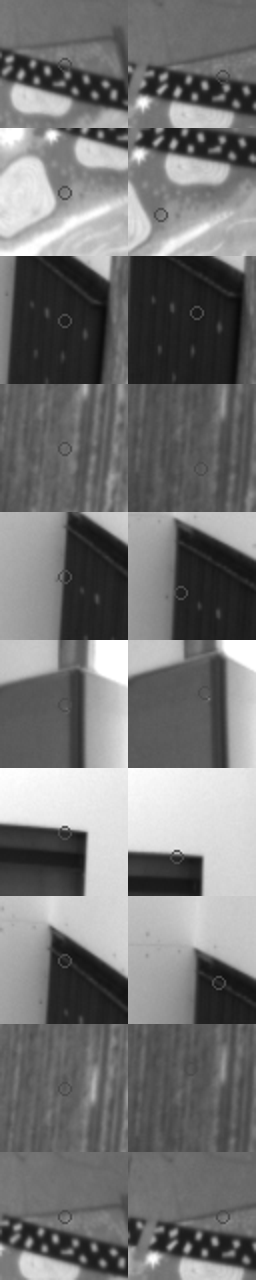

In [45]:
to_pil = T.ToPILImage()

num_patches = reference_patches.size(1)  # Should be 10 patches
patch_size = 128  # Resized to 128x128

combined_width = patch_size * 2  # Each pair takes up width of 2 patches
combined_height = num_patches * patch_size  # Height for all pairs

combined_image = Image.new('RGB', (combined_width, combined_height))

# Loop through each patch pair and paste into the combined image
for j in range(num_patches):  # 0 to 9 for 10 patches
    # Convert and resize patches
    img1 = to_pil(reference_patches[0, j]).resize((patch_size, patch_size))  # Resize to 128x128
    img2 = to_pil(target_patches[0, j]).resize((patch_size, patch_size))  # Resize to 128x128

    # Calculate positions
    y = j * patch_size  # Position for the current row
    x1 = 0               # Position for img1 (reference patch)
    x2 = patch_size      # Position for img2 (target patch)

    # Paste images into the combined image
    combined_image.paste(img1, (x1, y))  # Paste reference patch
    combined_image.paste(img2, (x2, y))  # Paste target patch

combined_image

# Check Model

In [21]:
samples = torch.randn_like(reference_patches)

if torch.cuda.is_available():
    samples = samples.cuda()
    
samples.shape

torch.Size([4, 10, 32, 32])

In [22]:
from model import KeypointMatcherModel
model = KeypointMatcherModel()

if torch.cuda.is_available():
    model = model.cuda()

In [23]:
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_trainable_params

596384

In [24]:
start_time = time.time()
out = model(samples)
end_time = time.time()

print(f"Output shape: {out.shape}")
print(f"Time taken for forward pass: {end_time - start_time:.6f} seconds")

DEBUG    | forward | Input shape: torch.Size([4, 10, 32, 32])
DEBUG    | forward | After ResidualBlock 1 : torch.Size([4, 32, 32, 32])
DEBUG    | forward | After ResidualBlock 2 : torch.Size([4, 64, 32, 32])
DEBUG    | forward | After ResidualBlock 3 : torch.Size([4, 128, 32, 32])
DEBUG    | forward | After ResidualBlock 4 : torch.Size([4, 128, 32, 32])
Output shape: torch.Size([4, 128, 32, 32])
Time taken for forward pass: 0.020362 seconds
